# Toroidal VAE
### Template Space S¹x...xS¹

In [1]:
import os
import sys

mvae_dir = os.path.split(os.getcwd())[0]
if mvae_dir not in sys.path:
    sys.path.append(mvae_dir)

In [2]:
%pwd
%load_ext autoreload
%autoreload 2

### Imports

In [3]:
import torch
import numpy as np
import torch.optim as optim

import lib.dataloaders.synthetic_loader as dataloader
import lib.models.vae.vm_toroidal_vae as model
import lib.trainer as trainer
import lib.utils as utils

from types import SimpleNamespace



### General set up

In [4]:
# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

### Experiment Configurations

In [5]:
loader_config = {
    "dataset_name": "s1_synthetic",
    "batch_size": 128,
    "synthetic_rotation": "random",
    "n_times": 10000,
    "radius": 19.0,
    "n_wiggles": 19,
    "geodesic_distortion_amp": 0.1,
    "embedding_dim": 10,
    "noise_var": 0.0001,
    "geodesic_distortion_func": "wiggles",
    "plot_dataset": True
}

model_config = {
    'data_dim': loader_config["embedding_dim"],
    'latent_dim': 1, 'sftbeta': 1,
    'device': "cpu",
    'encoder_width': 5,
    'encoder_depth': 2,
    'decoder_width': 5,
    'decoder_depth': 1
}

trainer_config = {
    'num_epochs': 1,
    'log_interval': 100,
    'device': "cpu",
    'recon_loss': "MSE"
}

misc_config = {
    "n_grid_points": 2000,  # to compute curvature
    "manifold_dim": 1,
}

config_dict = {}
config_dict.update(loader_config)
config_dict.update(model_config)
config_dict.update(trainer_config)
config_dict.update(misc_config)

config = SimpleNamespace(**config_dict)

 ### Dataloader

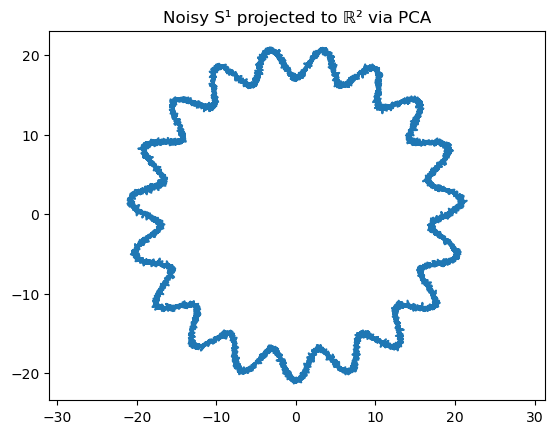

In [6]:
dataloader = dataloader.load_synthetic_ds(loader_config)
train_loader, test_loader = dataloader

### Model

In [7]:
toroidal_model = model.VMToroidalVAE(model_config)

### Optimizer

In [8]:
learning_rate = 0.001

toroidal_optimizer = optim.Adam(toroidal_model.parameters(), lr=learning_rate)

### Train and evaluate model

In [9]:
toroidal_history = trainer.MVAETrainer(toroidal_model, dataloader, toroidal_optimizer, trainer_config).train()

Trainer successfully initialized.
Training the vm_toroidalVAE model.
Starting epoch 1/1
Epoch 1/1, Train Loss: 365.0024, Test Loss: 362.7249
--------------------------------------------------


### Visualization 

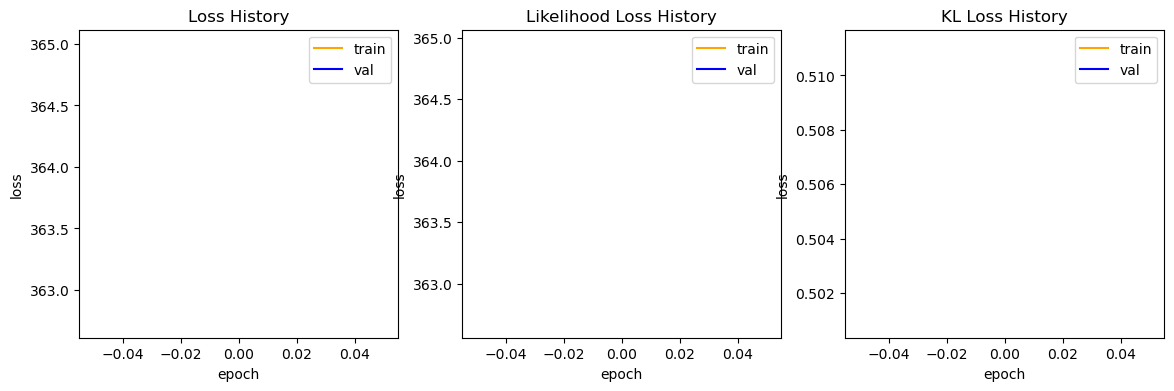

In [10]:
utils.show_training_history(toroidal_history)

#### Plot latent space

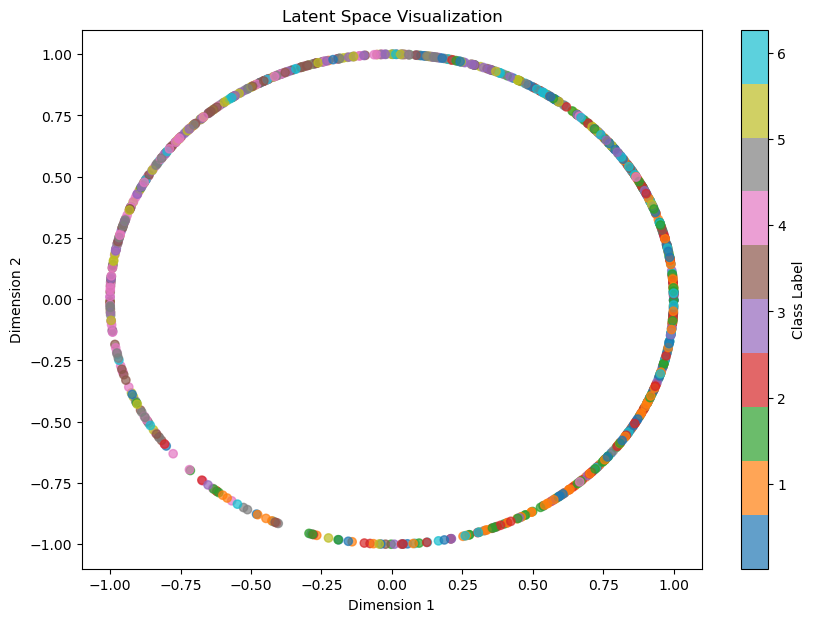

In [11]:
utils.plot_euclidean_latent_space(toroidal_model, test_loader, n_samples=10000)

#### Compute curvature error

In [12]:
all_data = []
all_labels = []

for data, labels in test_loader:
    all_data.append(data)
    all_labels.append(labels)

all_data = torch.cat(all_data)
all_labels = torch.cat(all_labels)
utils.curvature_compute_plot(config, all_data, all_labels, toroidal_model)

Computing learned curvature...


RuntimeError: The Tensor returned by the function given to hessian should contain a single element

### Save trained models

In [ ]:
#modelutils.save_model(toroidal_model, model_config)

### Load pretrained models

In [ ]:
#model = modelutils.load_model("gaussian_1740054584")
#model = toroidal_model

### Visualizing the latent space

In [ ]:
#utils.plot_test_latents_on_torus(toroidal_model, test_loader, device)

#### Visualize reconstructed mnist images

In [ ]:
#utils.show_recon_mnist(toroidal_model, test_loader, device)